In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("synthetic_dataset.csv")
df.head()

,Category,Price,Rating,Stock,Discount
0,NaN,5548.0,1.870322,NaN,0.0
1,NaN,3045.0,4.757798,NaN,38.0
2,NaN,4004.0,NaN,In Stock,0.0
3,NaN,4808.0,1.492085,NaN,33.0
4,NaN,1817.0,NaN,Out of Stock,23.0


In [3]:
df.tail()

,Category,Price,Rating,Stock,Discount
4357,NaN,4436.0,4.728335,NaN,49.0
4358,B,6236.0,NaN,Out of Stock,4.0
4359,NaN,3283.0,NaN,Out of Stock,9.0
4360,D,2999.0,4.425995,NaN,40.0
4361,NaN,NaN,2.184471,NaN,0.0


In [4]:
df.shape

(4362, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4362 entries, 0 to 4361
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  1614 non-null   object 
 1   Price     4188 non-null   float64
 2   Rating    2312 non-null   float64
 3   Stock     3010 non-null   object 
 4   Discount  3970 non-null   float64
dtypes: float64(3), object(2)
memory usage: 170.5+ KB


In [6]:
df.isnull().sum()

Category    2748
Price        174
Rating      2050
Stock       1352
Discount     392
dtype: int64

In [7]:
df.dtypes

Category     object
Price       float64
Rating      float64
Stock        object
Discount    float64
dtype: object

In [8]:
df.describe()

,Price,Rating,Discount
count,4188.000000,2312.000000,3970.000000
mean,5016.970630,3.038293,24.516625
std,2839.984813,1.143074,14.347164
min,102.000000,1.000366,0.000000
25%,2628.250000,2.069490,12.000000
50%,4996.500000,3.082060,25.000000
75%,7418.000000,4.008620,37.000000
max,9999.000000,4.997818,49.000000


In [9]:
## Identifying the Numerical column
numerical_col=df.select_dtypes(include=['int64','float64']).columns
print("Numerical Columns:",numerical_col)

Numerical Columns: Index(['Price', 'Rating', 'Discount'], dtype='object')


In [10]:
## Identifying the Categorical Column
cat_col=df.select_dtypes(include=['object']).columns
cat_col

Index(['Category', 'Stock'], dtype='object')

## Task-2 -> Missing Value Audit

In [11]:
miising_count=df.isnull().sum()
miising_count

Category    2748
Price        174
Rating      2050
Stock       1352
Discount     392
dtype: int64

In [12]:
miising_percentage=(df.isnull().sum()/len(df))*100
miising_percentage

Category    62.998624
Price        3.988996
Rating      46.996790
Stock       30.994956
Discount     8.986703
dtype: float64

In [13]:
missing_table=pd.DataFrame({
    "Missing_Count":df.isnull().sum(),
    "Missing_Percentage":(df.isnull().sum()/len(df))*100
})
missing_table=missing_table.sort_values(by="Missing_Percentage",ascending=False)
missing_table

,Missing_Count,Missing_Percentage
Category,2748,62.998624
Rating,2050,46.996790
Stock,1352,30.994956
Discount,392,8.986703
Price,174,3.988996


## Task-3 Visualize the missing Data

In [14]:
missing_df=df.isnull()
fig=px.imshow(
    missing_df,
    aspect="auto",
    title="Missing Values Heatmap")
fig.update_layout(
    xaxis_title="Columns",
    yaxis_title="Rows")
fig.show()

In [15]:
missing_df=(df.isnull()/len(df))*100
missing_df=miising_percentage.reset_index()
missing_df.columns=["Columns","Missing_Percentage"]
missing_df=missing_df.sort_values(by="Missing_Percentage",ascending=False)
missing_df

,Columns,Missing_Percentage
0,Category,62.998624
2,Rating,46.996790
3,Stock,30.994956
4,Discount,8.986703
1,Price,3.988996


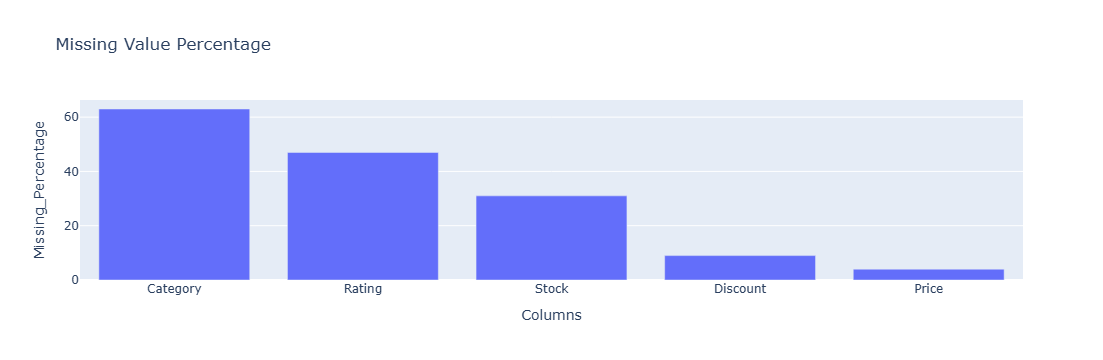

In [16]:
fig=go.Figure()
fig.add_bar(
    x=missing_df["Columns"],
    y=missing_df["Missing_Percentage"])
fig.update_layout(
    title="Missing Value Percentage",
    xaxis_title="Columns",
    yaxis_title="Missing_Percentage")
fig.show()

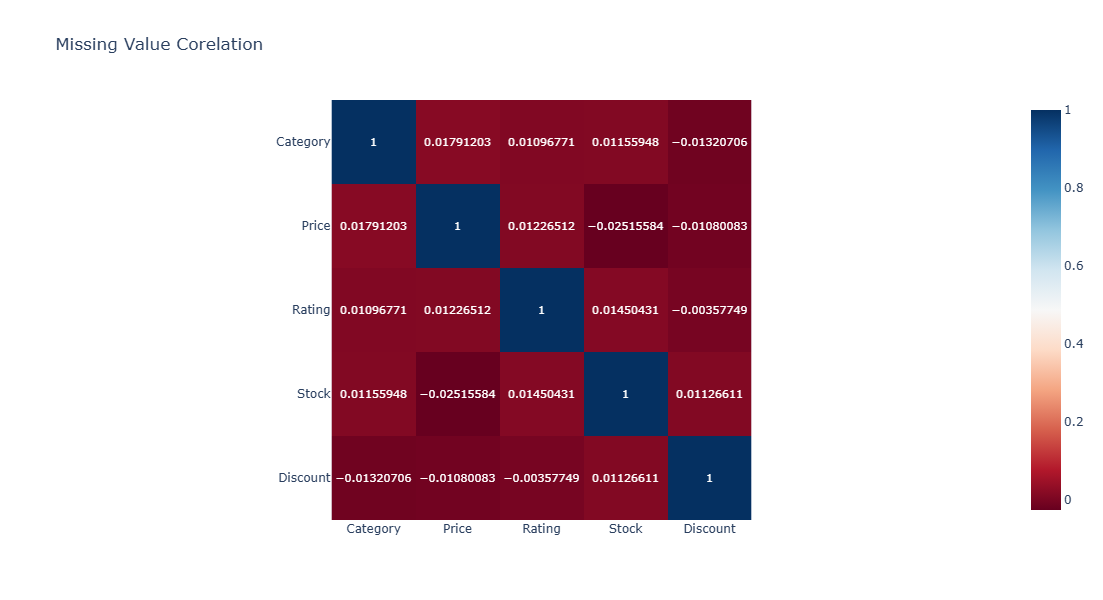

In [17]:
missing_corr=df.isnull().corr()
fig=px.imshow(
    missing_corr,
    text_auto=True,
    color_continuous_scale="RdBu",
    title="Missing Value Corelation")
fig.update_layout(
    width=1000,
    height=600)
fig.show()

## Task 4: Drop High-Missing Columns

In [18]:
df.Category.value_counts()

Category
C    425
D    408
A    403
B    378
Name: count, dtype: int64

In [19]:
threshold=0.60
missing_percentage=df.isnull().mean()
missing_percentage

Category    0.629986
Price       0.039890
Rating      0.469968
Stock       0.309950
Discount    0.089867
dtype: float64

In [20]:
col_to_drop=missing_percentage[missing_percentage>threshold].index
col_to_drop

Index(['Category'], dtype='object')

In [21]:
df=df.drop(columns=col_to_drop)
df.head()

,Price,Rating,Stock,Discount
0,5548.0,1.870322,NaN,0.0
1,3045.0,4.757798,NaN,38.0
2,4004.0,NaN,In Stock,0.0
3,4808.0,1.492085,NaN,33.0
4,1817.0,NaN,Out of Stock,23.0


In [22]:
df

,Price,Rating,Stock,Discount
0,5548.0,1.870322,NaN,0.0
1,3045.0,4.757798,NaN,38.0
2,4004.0,NaN,In Stock,0.0
3,4808.0,1.492085,NaN,33.0
4,1817.0,NaN,Out of Stock,23.0
...,...,...,...,...
4357,4436.0,4.728335,NaN,49.0
4358,6236.0,NaN,Out of Stock,4.0
4359,3283.0,NaN,Out of Stock,9.0
4360,2999.0,4.425995,NaN,40.0


In [23]:
df["missing_count"]=df.isnull().sum(axis=1)


In [24]:
df.head()

,Price,Rating,Stock,Discount,missing_count
0,5548.0,1.870322,NaN,0.0,1
1,3045.0,4.757798,NaN,38.0,1
2,4004.0,NaN,In Stock,0.0,1
3,4808.0,1.492085,NaN,33.0,1
4,1817.0,NaN,Out of Stock,23.0,1


In [25]:
df = df[df.isnull().sum(axis=1) <= 3]
df = df.drop(columns=["missing_count"])

In [26]:
df

,Price,Rating,Stock,Discount
0,5548.0,1.870322,NaN,0.0
1,3045.0,4.757798,NaN,38.0
2,4004.0,NaN,In Stock,0.0
3,4808.0,1.492085,NaN,33.0
4,1817.0,NaN,Out of Stock,23.0
...,...,...,...,...
4357,4436.0,4.728335,NaN,49.0
4358,6236.0,NaN,Out of Stock,4.0
4359,3283.0,NaN,Out of Stock,9.0
4360,2999.0,4.425995,NaN,40.0


## Task 6: Numerical Imputation – Basic

In [27]:
num_cols=df.select_dtypes(include=["int64","float64"])
skewness=num_cols.skew()
print(skewness)
## For me
# 0->Perfectly Normal
# >1 ->Highely skewed 
# <-1 -> Negatively Skewed

Price       0.007415
Rating     -0.056286
Discount   -0.009762
dtype: float64


In [28]:
num_cols=df.select_dtypes(include=["int64","float64"]).columns

In [29]:
print(df[num_cols].dtypes)

Price       float64
Rating      float64
Discount    float64
dtype: object


In [30]:
df_mean=df.copy()
df_mean[num_cols]=df_mean[num_cols].fillna(df_mean[num_cols].mean())
df_mean.head()

,Price,Rating,Stock,Discount
0,5548.0,1.870322,NaN,0.0
1,3045.0,4.757798,NaN,38.0
2,4004.0,3.038293,In Stock,0.0
3,4808.0,1.492085,NaN,33.0
4,1817.0,3.038293,Out of Stock,23.0


In [31]:
df_median=df.copy()
df_median[num_cols]=df_median[num_cols].fillna(df[num_cols].median())
df_median.head()

,Price,Rating,Stock,Discount
0,5548.0,1.870322,NaN,0.0
1,3045.0,4.757798,NaN,38.0
2,4004.0,3.082060,In Stock,0.0
3,4808.0,1.492085,NaN,33.0
4,1817.0,3.082060,Out of Stock,23.0


In [32]:
import plotly.express as px

fig = px.histogram(df, x="Price", title="Original Price Distribution")
fig.show()

fig = px.histogram(df_mean, x="Price", title="Price Distribution After Mean Imputation")
fig.show()

fig = px.histogram(df_median, x="Price", title="Price Distribution After Median Imputation")
fig.show()

In [33]:
fig = px.histogram(df, x="Rating", title="Original Rating Distribution")
fig.show()

fig = px.histogram(df_mean, x="Rating", title="Rating Distribution After Mean Imputation")
fig.show()

fig = px.histogram(df_median, x="Rating", title="Rating Distribution After Median Imputation")
fig.show()

In [34]:
fig = px.histogram(df, x="Discount", title="Original Discount Distribution")
fig.show()

fig = px.histogram(df_mean, x="Discount", title="Discount Distribution After Mean Imputation")
fig.show()

fig = px.histogram(df_median, x="Discount", title="Discount Distribution After Median Imputation")
fig.show()

## Handling imbalance dataset  

In [35]:
df=pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [36]:
len(df.columns)

31

In [37]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [38]:
df.shape

(284807, 31)

In [39]:
class_counts=df["Class"].value_counts()
class_counts

Class
0    284315
1       492
Name: count, dtype: int64

In [40]:
class_percentage=df['Class'].value_counts(normalize=True)*100
class_percentage

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [41]:
import plotly.graph_objects as go
fig=go.Figure()
fig.add_trace(go.Bar(
    x=class_counts.index,
    y=class_counts.values))
fig.update_layout(
    title="Class Distribution",
    xaxis_title="Class",
    yaxis_title="Number of Transactions",
    width=1000,
    height=500)
fig.show()

In [42]:
X=df.drop("Class",axis=1)
y=df["Class"]

In [43]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [44]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [45]:
y_pred=model.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

print("Accuracy Score:",accuracy)
print("Precision Score:",precision)
print("Recall:",recall)
print("F1-Score:",f1)

Accuracy Score: 0.9992802219023208
Precision Score: 0.8518518518518519
Recall: 0.7040816326530612
F1-Score: 0.770949720670391


In [47]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [48]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
from imblearn.under_sampling import RandomUnderSampler
x=df.drop("Class",axis=1)
y=df["Class"]
rus=RandomUnderSampler(random_state=42)
X_res,y_res=rus.fit_resample(X,y)
print("After RUS:",X_res.shape)
print(y_res.value_counts())

After RUS: (984, 30)
Class
0    492
1    492
Name: count, dtype: int64


In [50]:
from sklearn.ensemble import RandomForestClassifier
X_train,X_test,y_train,y_test=train_test_split(X_res,y_res,test_size=0.2,random_state=42)
model=RandomForestClassifier()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [51]:
X_train.shape

(787, 30)

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.9187817258883249
Precision: 0.9555555555555556
Recall: 0.8775510204081632
F1: 0.9148936170212766


In [53]:
## RandomOverSampler
from imblearn.over_sampling import RandomOverSampler
X=df.drop("Class",axis=1)
y=df["Class"]
ros=RandomOverSampler(random_state=42)
X_res,y_res=ros.fit_resample(X,y)
print("After ROS Shape:", X_res.shape)
print(y_res.value_counts())

After ROS Shape: (568630, 30)
Class
0    284315
1    284315
Name: count, dtype: int64


In [54]:
from sklearn.ensemble import RandomForestClassifier
X_train,X_test,y_train,y_test=train_test_split(X_res,y_res,test_size=0.2,random_state=42)
model=RandomForestClassifier()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.9999560346798445
Precision: 0.9999122514522385
Recall: 1.0
F1: 0.9999561238010829


In [56]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [57]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [58]:
print("Before SMOTE:",y_train.value_counts())
print("After SMOTE:",y_train_sm.value_counts())

Before SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


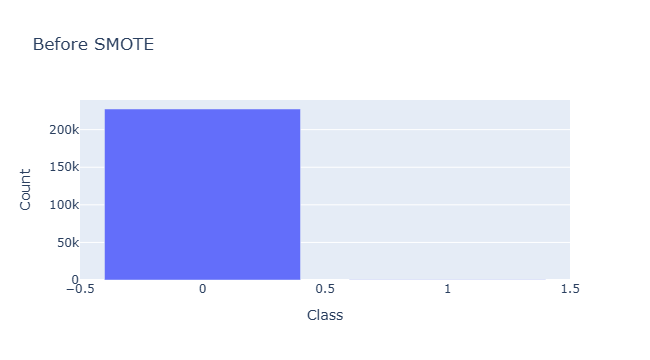

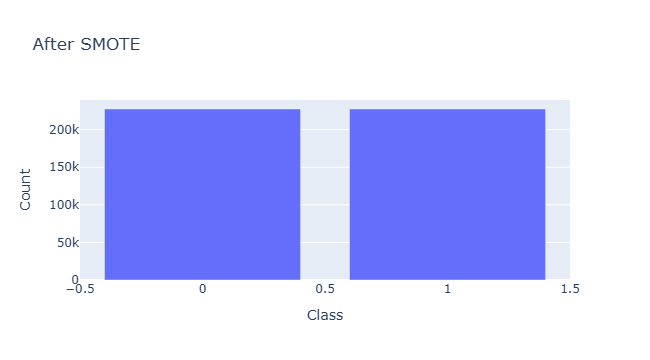

In [59]:
before=y_train.value_counts().reset_index()
before.columns=["Class","Count"]
after=y_train_sm.value_counts().reset_index()
after.columns=["Class","Count"]
px.bar(before,x="Class",y="Count",title="Before SMOTE").show()
px.bar(after,x="Class",y="Count",title="After SMOTE").show()


In [60]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(random_state=42)
model.fit(X_train_sm,y_train_sm)
y_pred=model.predict(X_test)

In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.999403110845827
Precision: 0.826530612244898
Recall: 0.826530612244898
F1: 0.826530612244898
